In [126]:
import pandas as pd

df_SL = pd.read_csv('z_score_df_SL_over_US_071626.csv').set_index('peptide')

df_SL_rpk = pd.read_csv('./preprocessing/earliest_tp_rpk_avg_value_for_cohort_techreps_071626.csv').set_index('peptide')

df_hbdb = pd.read_csv('z_hbdb_loo_results_071626.csv').set_index('peptide')

df_hbdb_rpk = pd.read_csv('./preprocessing/hbdb_pass_100k_techreps_averaged_071626.csv').set_index('peptide')
sig_peps = pd.read_csv('indices_peps_sig_pos_d_z_071626.csv').set_index('peptide')

peps_metadata = pd.read_csv('lassa_library_sequences_species_standardized_070726.csv').set_index('seq_id')

In [127]:
#log transform the rpk matrices same way as for the z score analysis 
import pandas as pd
import numpy as np

df_SL_rpk = df_SL_rpk.apply(pd.to_numeric, errors="coerce").fillna(0.0) #converts every column to a numeric type, if cannot be converted, fills with Nan, but then later NaN gets converted to 0.0

df_SL_log_rpk = np.log10(df_SL_rpk + 1.0)

df_hbdb_rpk = df_hbdb_rpk.apply(pd.to_numeric, errors='coerce').fillna(0.0) #converts every column to a numeric type, if cannot be converted, fills with Nan, but then later NaN gets converted to 0.0

df_hbdb_log_rpk = np.log10(df_hbdb_rpk + 1.0)

In [128]:
print("raw min/max:", df_SL_rpk.min().min(), df_SL_rpk.max().max())
print("log min/max:", df_SL_log_rpk.min().min(), df_SL_log_rpk.max().max())

raw min/max: 0.0 47695.75196486842
log min/max: 0.0 4.678488805627892


In [129]:
#subset to only significant peptides 

peps_metadata = peps_metadata.loc[sig_peps.index]

In [130]:
import numpy as np

df_plot = pd.concat([df_SL, df_hbdb], axis=1)

df_plot_log_rpk = pd.concat([df_SL_log_rpk, df_hbdb_log_rpk], axis=1)


In [131]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np


def species_boxplot(data,  metadata, species:str, agg = "mean", dtype = "z_score"):
    """
    Parameters:
    - data: Pandas DataFrame containing the z score data 
    - x_var: column name 

    """
    species_peps = metadata[metadata['species'] == species]
    df_subset = data.loc[species_peps.index]


    
    #define group Sierra Leone (SL) vs HBDB
    sl_cols = [c for c in df_subset.columns if c.startswith(("C", "S"))]
    hbdb_cols = [c for c in df_subset.columns if c.startswith("HBDB")]

    #with the agg function, each individual (column) gets one value. returns a Series, so a single vector

    if agg == 'mean':
        sl_summary = df_subset[sl_cols].mean(axis=0, skipna=True)
        hbdb_summary=df_subset[hbdb_cols].mean(axis=0, skipna=True)

    elif agg == 'median':
        sl_summary = df_subset[sl_cols].median(axis=0, skipna=True)
        hbdb_summary=df_subset[hbdb_cols].median(axis=0, skipna=True)

    elif agg == 'max':
        sl_summary = df_subset[sl_cols].max(axis=0, skipna=True)
        hbdb_summary=df_subset[hbdb_cols].max(axis=0, skipna=True)

    elif agg == 'sum':
        sl_summary = df_subset[sl_cols].sum(axis=0, skipna=True)
        hbdb_summary=df_subset[hbdb_cols].sum(axis=0, skipna=True)

    else:
        raise ValueError("agg must be one of: 'mean', 'median' 'max', 'sum'")
    
    print(sl_summary)
    print(hbdb_summary)

    plot_df = pd.DataFrame({
        "value": pd.concat([sl_summary, hbdb_summary], axis=0).values,
        "group": ["SL"] * len(sl_summary.index)+ ["HBDB"] * len(hbdb_summary.index),
        "individual": list(sl_summary.index) +list(hbdb_summary.index)
    })

    
    print(df_subset.columns.tolist())
    
    sns.boxplot(data = plot_df, x = "group", y = "value")
    sns.stripplot(data=plot_df, x="group", y="value", color="black", alpha=0.6, jitter=True)
    plt.title(f"{species} peptides {agg} {dtype} per individual")
    plt.ylabel(f'{agg} {dtype} score')
    plt.show()




In [132]:
species = ["Mammarenavirus lassaense", "Plasmodium falciparum", "Orthoflavivirus zikaense", "Orthoflavivirus denguei", "Orthonairovirus haemorrhagiae", "Trypanosoma cruzi"]

C-109-3_4_E7     87.043892
C-111-3_3_I6    290.996376
C-112-1_3_B3     81.897675
C-130-2_3_C3    -26.902836
C-135-2_1_D2    -31.282557
                   ...    
S-505_SA3_H4    -99.495363
S-506_SA3_H9   -405.177738
S-511_SA5_A6   -204.967864
S-512_SA3_G9    152.757298
S-513_SA3_I2   -641.776831
Length: 397, dtype: float64
HBDB-001   -142.771642
HBDB-010     56.901118
HBDB-021    148.271880
HBDB-030   -171.974479
HBDB-038   -113.492962
               ...    
HBDB-106    414.189855
HBDB-107     62.619987
HBDB-109    -97.748602
HBDB-111     75.700382
HBDB-115   -110.241538
Length: 87, dtype: float64
['C-109-3_4_E7', 'C-111-3_3_I6', 'C-112-1_3_B3', 'C-130-2_3_C3', 'C-135-2_1_D2', 'C-140-1_1_A7', 'C-144-2_2_B5', 'C-147-2_1_F5', 'C-150-2_1_H3', 'C-183-1_1_F4', 'C-192-3_1_D3', 'C-434-3_5_E2', 'C-438-1_3_A4', 'C-441-3_2_G4', 'C-444-2_2_E4', 'C-464-3_3_F9', 'C-467-3_2_D5', 'C-470-3_2_F8', 'C-475-2_2_F5', 'C-483-1_1_D9', 'C-484-2_3_D4', 'C-485-3_2_H3', 'C-489-2_3_D5', 'C-499-3_1_B2', 'C-505-2_4

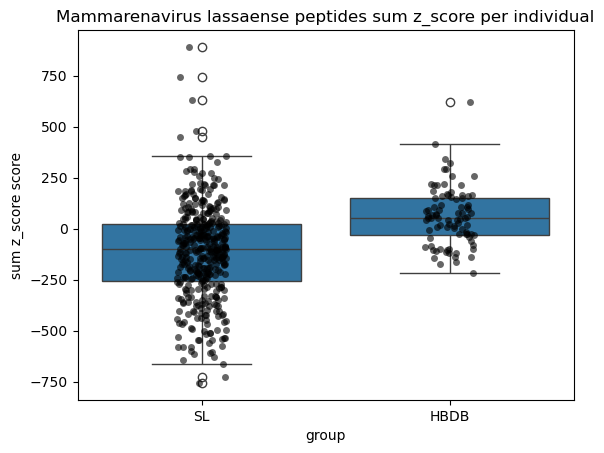

In [133]:
species_boxplot(data = df_plot, metadata = peps_metadata, species = 'Mammarenavirus lassaense', agg = 'sum')

C-109-3_4_E7    2.029065
C-111-3_3_I6    0.782605
C-112-1_3_B3    2.301710
C-130-2_3_C3    2.189902
C-135-2_1_D2    1.244992
                  ...   
S-505_SA3_H4    1.904737
S-506_SA3_H9    1.188680
S-511_SA5_A6    2.283112
S-512_SA3_G9    1.841309
S-513_SA3_I2    1.514744
Length: 397, dtype: float64
HBDB-001    0.405428
HBDB-010    0.463796
HBDB-021    0.427149
HBDB-030    0.294369
HBDB-038    0.363357
              ...   
HBDB-106    0.365271
HBDB-107    0.290493
HBDB-109    0.576895
HBDB-111    0.707381
HBDB-115    0.524418
Length: 87, dtype: float64
['C-109-3_4_E7', 'C-111-3_3_I6', 'C-112-1_3_B3', 'C-130-2_3_C3', 'C-135-2_1_D2', 'C-140-1_1_A7', 'C-144-2_2_B5', 'C-147-2_1_F5', 'C-150-2_1_H3', 'C-183-1_1_F4', 'C-192-3_1_D3', 'C-434-3_5_E2', 'C-438-1_3_A4', 'C-441-3_2_G4', 'C-444-2_2_E4', 'C-464-3_3_F9', 'C-467-3_2_D5', 'C-470-3_2_F8', 'C-475-2_2_F5', 'C-483-1_1_D9', 'C-484-2_3_D4', 'C-485-3_2_H3', 'C-489-2_3_D5', 'C-499-3_1_B2', 'C-505-2_4_C2', 'C-508-2_4_A8', 'S-107_SA1_A9', 'S-113

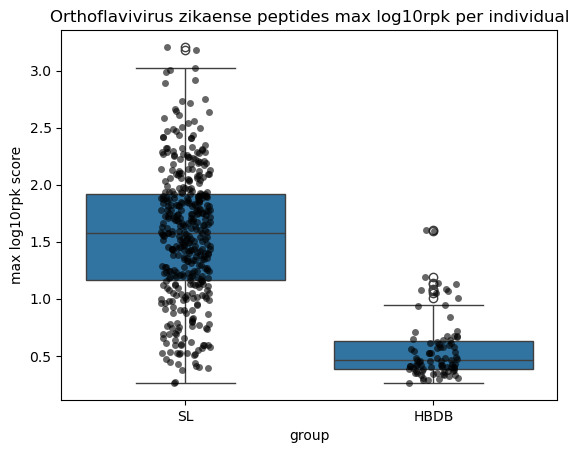

In [136]:
species_boxplot(data = df_plot_log_rpk, metadata = peps_metadata, species = 'Orthoflavivirus zikaense', agg = 'max', dtype='log10rpk')